In [1]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2
    
mne.set_log_level('ERROR')
tl.get_backend()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = EPFLP300()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
epochs

Number of events,854
Events,NonTarget: 712Target: 142
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
X = epochs.get_data()
y = labels

X.shape

(854, 32, 26)

In [5]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter, force_toeplitz,center
from hoda.backend import lobpcg
import cupyx.scipy.sparse.linalg
import warnings


from hoda.hoda import f_oneway, mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
    rank=4,
    max_iter=64,
    tol=1e-12,
    init ='mlsvd',
    shrinkage='lw',
    toeplitz=None,
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=True,
    verbose=True,

)

hoda.fit(X,y)

Fitting discriminative tensor model of rank (4, 4)...


  0%|          | 0/64 [00:00<?, ?it/s]

HODA(extra_train_info=True, init='mlsvd', max_iter=64, rank=4, solver='lobpcg',
     tol=1e-12, verbose=True)

In [6]:
import pandas as pd
df = pd.DataFrame(hoda.train_info_)
df

,iteration,mode,update,shrinkage,objective,F_tr,F_rt,mse
0,1,0,1.575808e-02,0.002499,859.783731,0.041422,0.001372,0.862173
1,1,1,1.862158e-02,0.009906,5706.948508,0.086014,0.001974,0.910954
2,2,0,4.766790e-03,0.003224,831.678700,0.086864,0.002287,0.861406
3,2,1,1.131537e-02,0.011339,5037.007724,0.096465,0.002346,0.883166
4,3,0,1.835824e-03,0.002564,715.916372,0.107958,0.002446,0.884192
...,...,...,...,...,...,...,...,...
93,47,1,1.863803e-12,0.011715,4063.735729,0.130099,0.002856,0.914665
94,48,0,6.407638e-13,0.003029,694.922300,0.130099,0.002856,0.914665
95,48,1,1.410531e-12,0.011715,4063.734395,0.130099,0.002856,0.914665
96,49,0,4.158279e-13,0.003029,694.920643,0.130099,0.002856,0.914665


In [7]:
from hoda.cov import center

_, X_centered = center(tl.tensor(X),y)
G = hoda.transform(X_centered)
X_approx = hoda.inv_transform(G)
err = X_centered-X_approx

<Axes: >

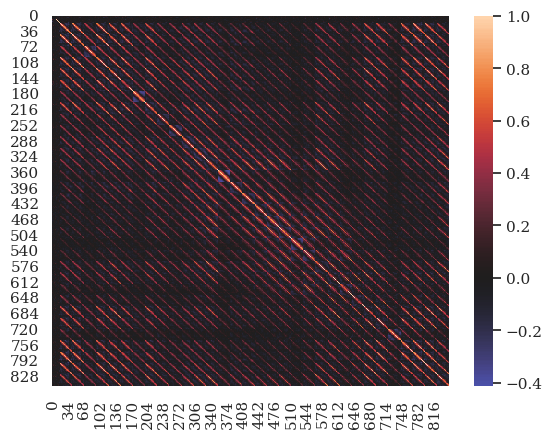

In [8]:
import seaborn as sns
import numpy as np
n_samples=X.shape[0]
G_flat = G.reshape((n_samples,-1))
err_flat = err.reshape((n_samples,-1))
c = tl.to_numpy(tl.concatenate([G_flat, err_flat], axis=1))
corr = np.corrcoef(c.T)
sns.heatmap(corr, center=0)

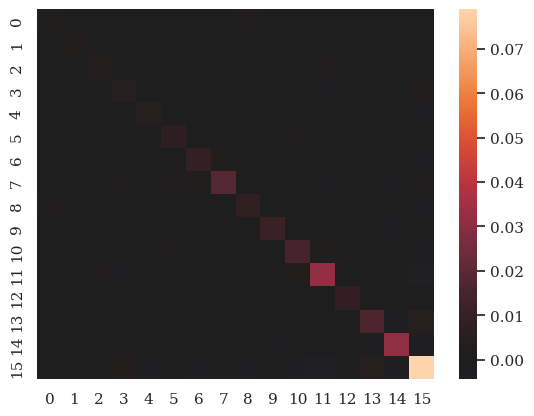

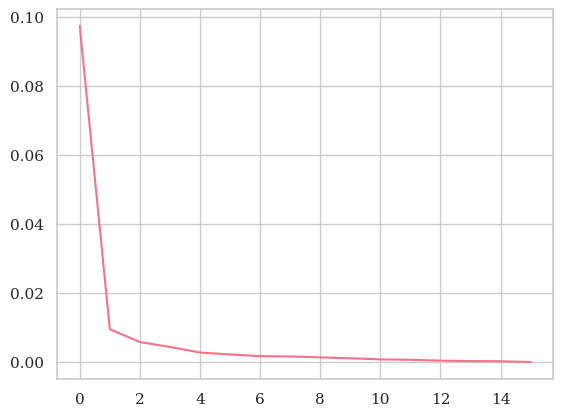

In [9]:
from hoda.cov import pvl_perm
import matplotlib.pyplot as plt

cov_G = np.cov(tl.to_numpy(G_flat), rowvar=False)

cov_G_pvl = pvl_perm(cov_G, G.shape[1], G.shape[2])

sns.heatmap(cov_G, center=0)
plt.show()
u,s,v = np.linalg.svd(cov_G_pvl)
plt.plot(s)

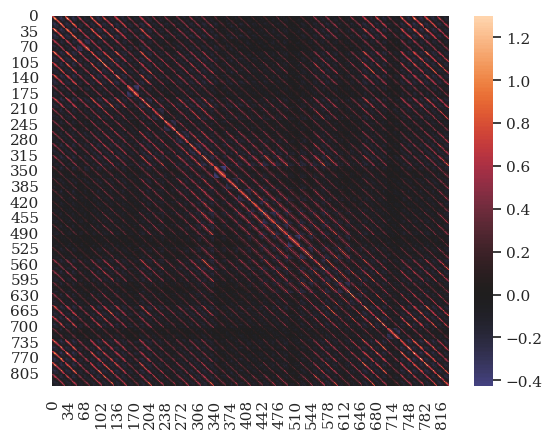

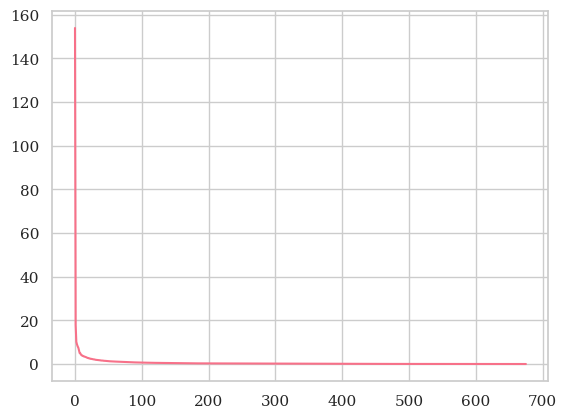

In [10]:
cov_X = np.cov(tl.to_numpy(X_centered.reshape((n_samples,-1))), rowvar=False)
sns.heatmap(cov_X, center=0)
plt.show()

cov_X_pvl = pvl_perm(cov_X, X.shape[1], X.shape[2])
u,s,v = np.linalg.svd(cov_X_pvl)
plt.plot(s)

In [11]:
cov_GE = tl.tenalg.tensordot(G,err, modes=[(0),(0)])


<Axes: xlabel='iteration', ylabel='objective'>

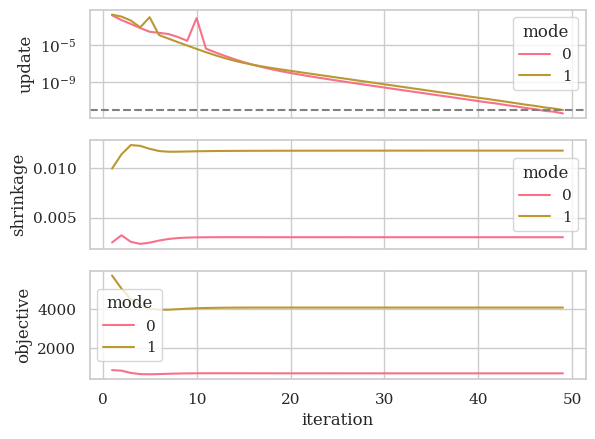

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])

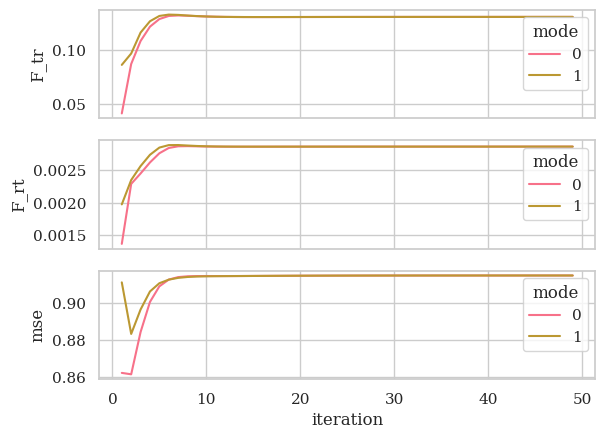

In [13]:
if hoda.extra_train_info:
    fig, axs = plt.subplots(3,1, sharex=True)
    sns.lineplot(data=df, x='iteration', y='F_tr', hue='mode', ax=axs[0])
    sns.lineplot(data=df, x='iteration', y='F_rt', hue='mode', ax=axs[1])
    sns.lineplot(data=df, x='iteration', y='mse', hue='mode', ax=axs[2])



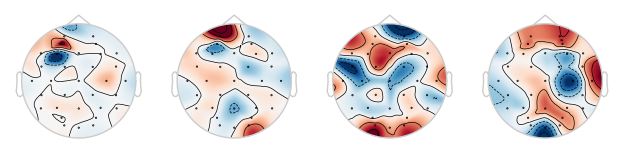

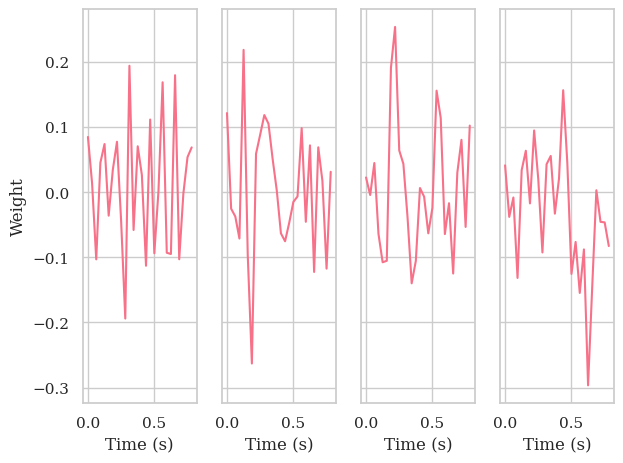

In [14]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.weights_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


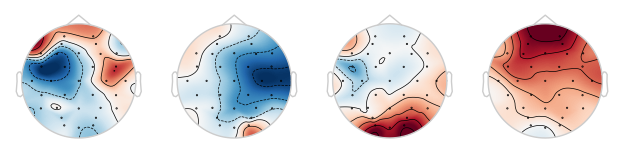

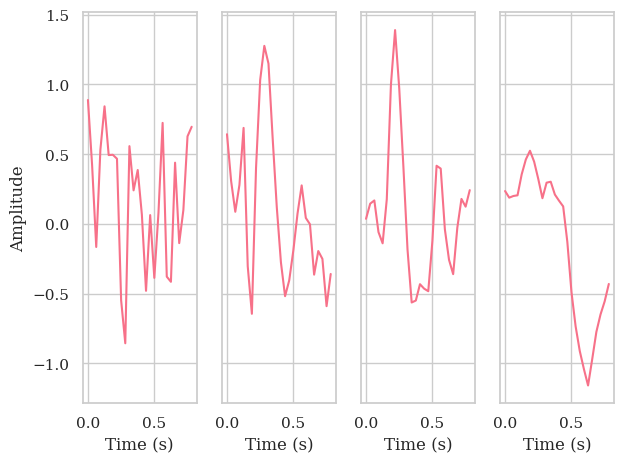

In [15]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


In [16]:
Xt = hoda.transform(X)

<BarContainer object of 4 artists>

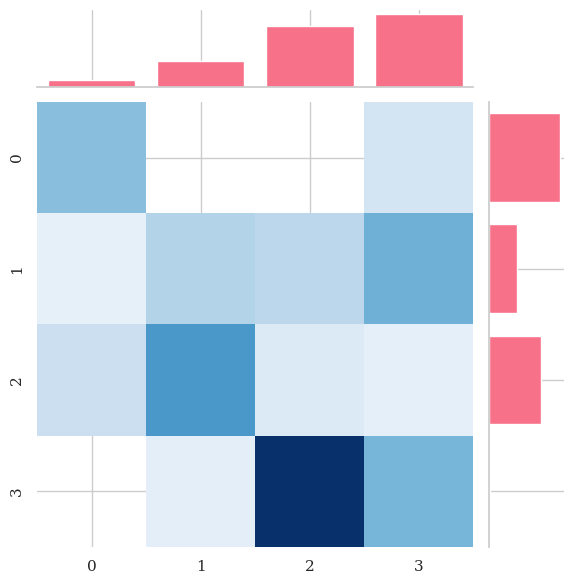

In [17]:
from hoda.hoda import f_multiway

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)



In [18]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(854, 16)

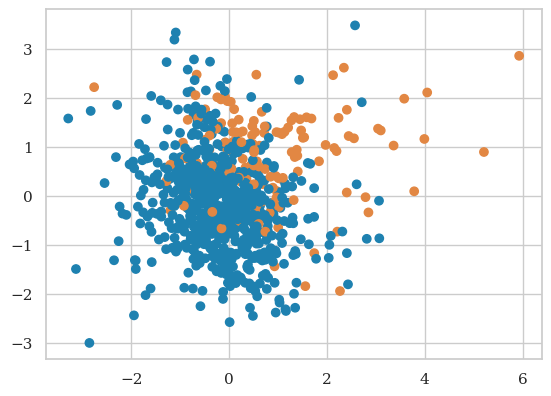

In [19]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

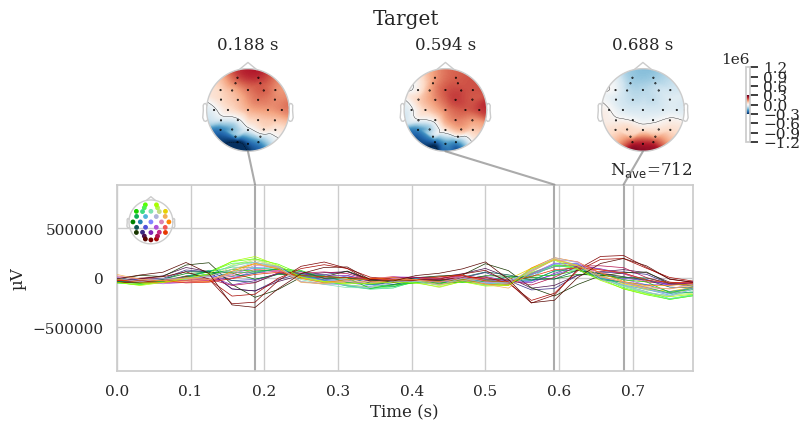

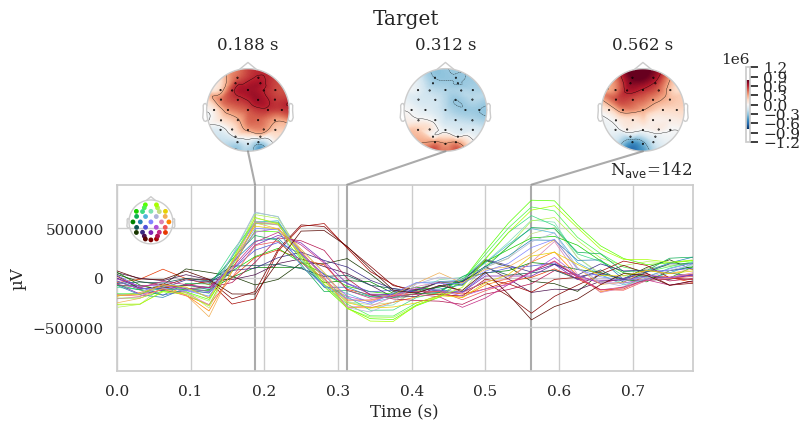

In [20]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

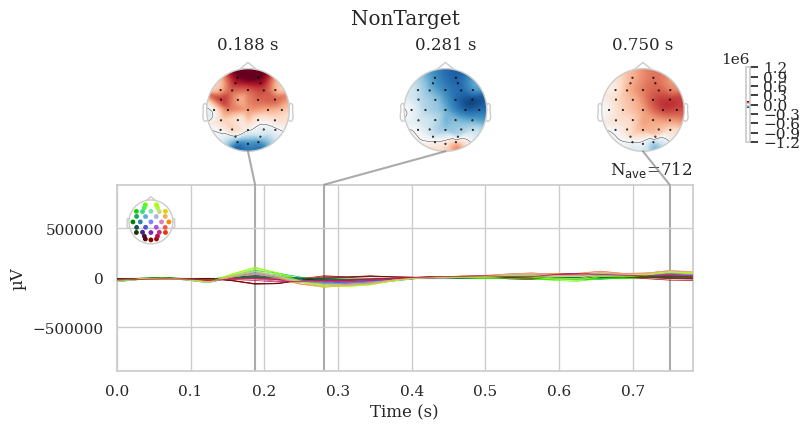

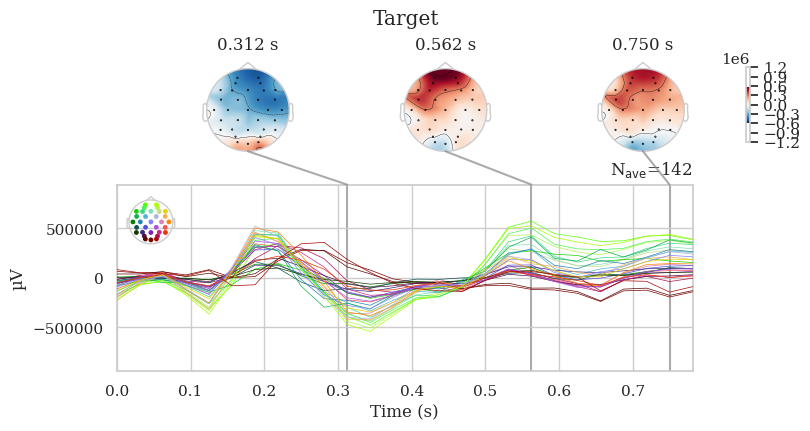

In [21]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,
                              **joint_args
                             )
    else:
        evoked_rec.plot(**ts_args)

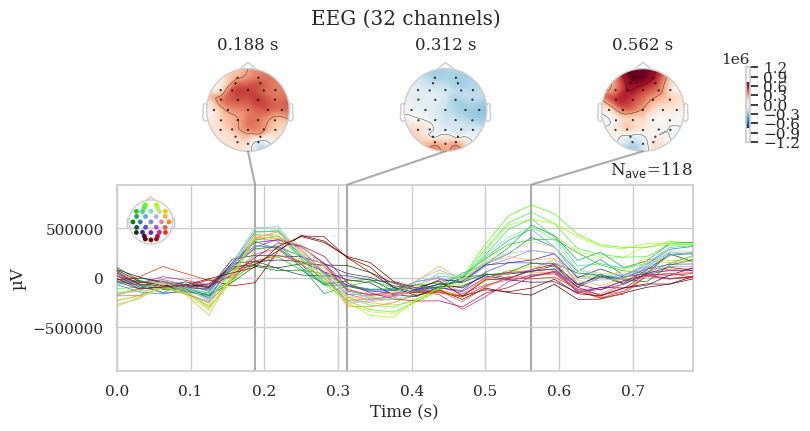

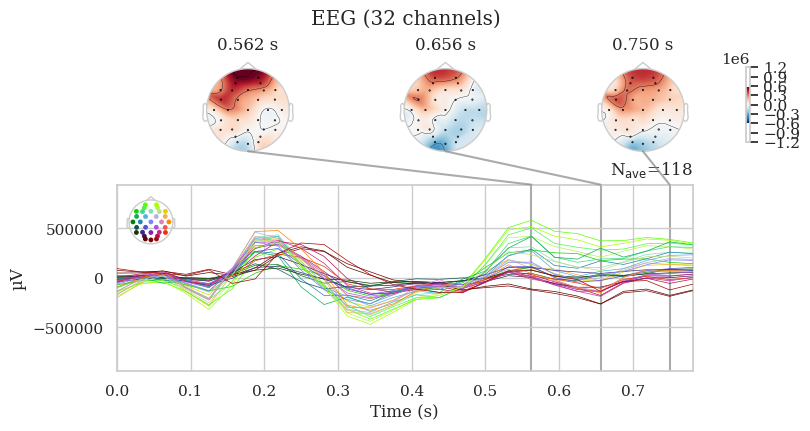

In [22]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(
    **joint_args
)


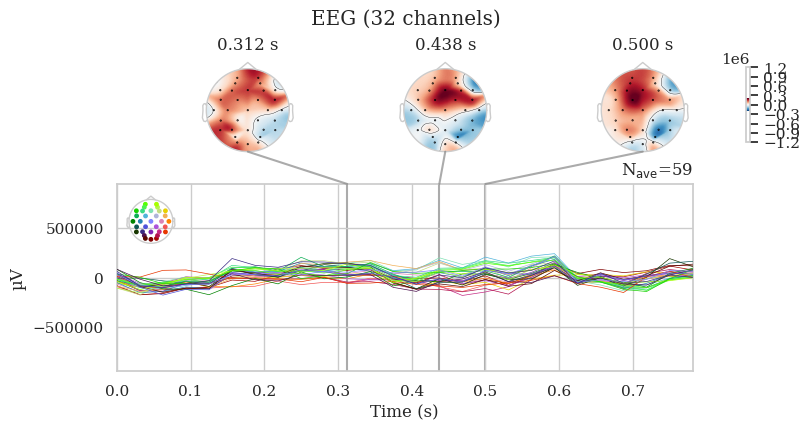

In [23]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)